## Описание датасета (Kaggle: Give me some credit)  
**Количество наблюдений:** 150k  

## Целевая переменная

- **SeriousDlqin2yrs (0 / 1)**  
  Имел ли заемщик просрочку **90 дней или более** за последние 2 года.

## Признаки

#### 1. Демография

- **age (int)**  
  Возраст заемщика (в годах)

- **NumberOfDependents (int)**  
  Количество иждивенцев, без учета самого заемщика (дети, супруг и др.)  

#### 2. Доход и долговая нагрузка

- **MonthlyIncome (float)**  
  Ежемесячный доход заемщика

- **DebtRatio (percentage)**  
  Отношение ежемесячных долговых обязательств к доходу. Включает алименты, выплаты по кредитам, базовые расходы на жизнь. 

#### 3. Кредитная нагрузка

- **RevolvingUtilizationOfUnsecuredLines (percentage)**  
  Доля использования необеспеченных кредитных линий  
  Рассчитывается как:
  > баланс по кредитным линиям / общий кредитный лимит
  
  Кредитная линия -- предустановленный лимит заемных средств. Напр., кредитные карты разных банков.  
  Необеспеченная кредитная линия -- без залога (не ипотека, не автокредит и т.д.)  

#### 4. Кредитная история

- **NumberOfOpenCreditLinesAndLoans (int)**  
  Общее количество открытых кредитов и кредитных линий  
  *(например: ипотека, автокредиты, кредитные карты)*

- **NumberRealEstateLoansOrLines (int)**  
  Количество кредитов, связанных с недвижимостью, включая кредитные линии под залог собственного капитала
  *(ипотека, кредит под залог недвижимости и т.д.)*

#### 5. История просрочек

- **NumberOfTime30-59DaysPastDueNotWorse (int)**  
  Количество просрочек от **30 до 59 дней**

- **NumberOfTime60-89DaysPastDueNotWorse (int)**  
  Количество просрочек от **60 до 89 дней**

- **NumberOfTimes90DaysLate (int)**  
  Количество просрочек **90+ дней**


## Гипотезы

1. (+-) Более молодые (age) заёмщики имеют повышенный риск дефолта  
2. (+-) Риск дефолта меньше, если выше доход (MonthlyIncome)  
3. (-) Заемщики с пропущенным значением MonthlyIncome имеют повышенный риск дефолта (скрывают доход?)
4. (+) Риск дефолта выше при низком MonthlyIncome и высоком NumberOfDependents
5. Риск дефолта напрямую взаимосвязан с признаками:
   - (+) NumberOfDependents (количество иждивенцев)
   - (-) DebtRatio (отношение долговых обязательств к доходу)
   - (+) RevolvingUtilizationOfUnsecuredLines
   - (+) Количество просрочек
6. (+-) Риск дефолта повышен при малом количестве кредитных линий NumberOfOpenCreditLinesAndLoans и снижается с их ростом, но существует "точка перегрузки" от большого количества кредитов, после которой риск дефолта вырастает

   

## 1. Data Overview

In [1]:
!pip install numpy pandas matplotlib seaborn pathlib plotly scipy

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import seaborn as sns

from pathlib import Path

mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "figure.facecolor": "#FFFFFF",
    "axes.grid":        False,
})

#### Data loading

In [3]:
DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "cs-training.csv"
TEST_PATH  = DATA_DIR / "cs-test.csv"

print(f"Train path : {TRAIN_PATH}  | exists: {TRAIN_PATH.exists()}")
print(f"Test  path : {TEST_PATH}   | exists: {TEST_PATH.exists()}")

Train path : data\cs-training.csv  | exists: True
Test  path : data\cs-test.csv   | exists: True


In [4]:
df = pd.read_csv(TRAIN_PATH, index_col=0)

#### Target info

In [5]:
df['SeriousDlqin2yrs'].describe()

count    150000.000000
mean          0.066840
std           0.249746
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: SeriousDlqin2yrs, dtype: float64

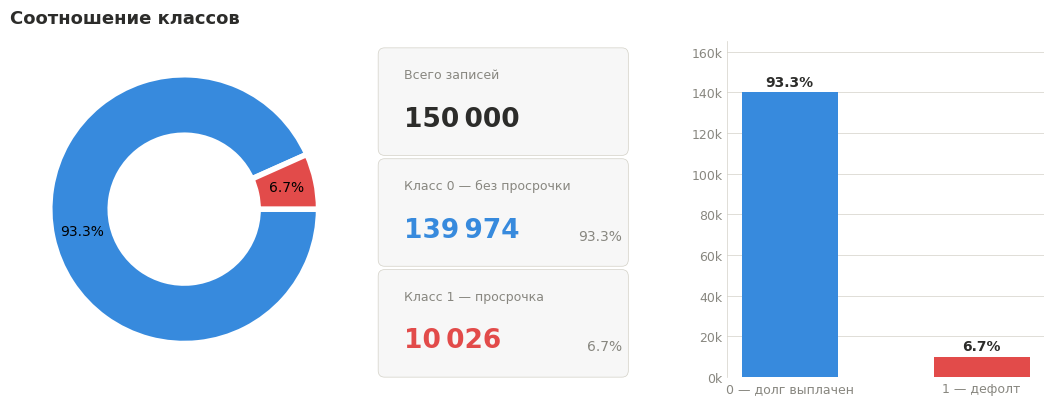

In [6]:
# ── data ───────────────────────────────────────────────────────────────────
counts = df["SeriousDlqin2yrs"].value_counts().sort_index()
total  = counts.sum()
n0, n1 = counts[0], counts[1]
p0, p1 = n0 / total * 100, n1 / total * 100

BLUE   = "#378ADD"
RED    = "#E24B4A"
BG     = "#F7F7F7"
TEXT   = "#2C2C2A"
MUTED  = "#888780"
BORDER = "#D3D1C7"

fig = plt.figure(figsize=(11, 4))
fig.text(0.03, 0.96, "Соотношение классов", fontsize=13, fontweight="bold", color=TEXT, va="top")

gs = GridSpec(1, 3, figure=fig, width_ratios=[1.1, 1, 1], left=0.03, right=0.97, top=0.88, bottom=0.04, wspace=0.08)

# ── donut ─────────────────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[0])
ax_d.set_facecolor("#FFFFFF")
wedges, texts, autotexts = ax_d.pie(
    [n0, n1],
    colors=[BLUE, RED],
    startangle=360,
    counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=4),
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.78,
    textprops=dict(color="black", fontsize=10),
)

# ── cards ─────────────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1])
ax_c.set_facecolor("#FFFFFF")
ax_c.axis("off")
ax_c.set_xlim(0, 1)
ax_c.set_ylim(0, 1)

cards = [
    ("Всего записей",           f"{total:,}".replace(",", "\u202f"), "",          TEXT,  0.68),
    ("Класс 0 — без просрочки", f"{n0:,}".replace(",",  "\u202f"),   f"{p0:.1f}%", BLUE, 0.35),
    ("Класс 1 — просрочка",     f"{n1:,}".replace(",",  "\u202f"),   f"{p1:.1f}%", RED,  0.02),
]
card_h = 0.28

for title, val, pct, col, y_bot in cards:
    box = mpatches.FancyBboxPatch((0, y_bot), 0.75, card_h, boxstyle="round,pad=0.02", linewidth=0.5, edgecolor=BORDER, facecolor=BG,
        transform=ax_c.transAxes, clip_on=False,
    )
    ax_c.add_patch(box)
    ax_c.text(0.06, y_bot + card_h - 0.04, title, transform=ax_c.transAxes, fontsize=9, color=MUTED, va="top")
    ax_c.text(0.06, y_bot + 0.05, val, transform=ax_c.transAxes, fontsize=19, fontweight="bold", color=col, va="bottom")
    if pct:
        ax_c.text(0.75, y_bot + 0.05, pct, transform=ax_c.transAxes, fontsize=10, color=MUTED, va="bottom", ha="right")

# ── bar chart ─────────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[2])
ax_b.set_facecolor("#FFFFFF")

bars = ax_b.bar([0, 1], [n0, n1], color=[BLUE, RED], width=0.5, zorder=3,)

for bar, pct in zip(bars, [p0, p1]):
    ax_b.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.012,
        f"{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color=TEXT,
    )

ax_b.set_xticks([0, 1])
ax_b.set_xticklabels(["0 — долг выплачен", "1 — дефолт"], fontsize=9, color=MUTED)
ax_b.set_ylim(0, max(n0, n1) * 1.18)
ax_b.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax_b.tick_params(axis="y", labelsize=9, labelcolor=MUTED, length=0)
ax_b.tick_params(axis="x", length=0)

# сетка и спайны
ax_b.yaxis.grid(True, color=BORDER, linewidth=0.5, zorder=0)
ax_b.set_axisbelow(True)
for spine in ["top", "right", "bottom"]:
    ax_b.spines[spine].set_visible(False)
ax_b.spines["left"].set_visible(True)
ax_b.spines["left"].set_color(BORDER)
ax_b.spines["left"].set_linewidth(0.5)

plt.savefig("target_distribution.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()

### Data info

In [7]:
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [9]:
data_dict = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Missing': df.isnull().sum().values,
    'Missing%': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': df.nunique().values,
    'Min': df.min().values,
    'Max': df.max().values,
    'Mean': df.mean().round(4).values,
    '25%': df.quantile(0.25, numeric_only=True).reindex(df.columns).values,
    '50%': df.quantile(0.50, numeric_only=True).reindex(df.columns).values,
    '75%': df.quantile(0.75, numeric_only=True).reindex(df.columns).values
})
data_dict.style.background_gradient(subset=['Missing%'], cmap='YlOrRd')

,Column,Type,Missing,Missing%,Unique,Min,Max,Mean,25%,50%,75%
0,SeriousDlqin2yrs,int64,0,0.000000,2,0.000000,1.000000,0.066800,0.000000,0.000000,0.000000
1,RevolvingUtilizationOfUnsecuredLines,float64,0,0.000000,125728,0.000000,50708.000000,6.048400,0.029867,0.154181,0.559046
2,age,int64,0,0.000000,86,0.000000,109.000000,52.295200,41.000000,52.000000,63.000000
3,NumberOfTime30-59DaysPastDueNotWorse,int64,0,0.000000,16,0.000000,98.000000,0.421000,0.000000,0.000000,0.000000
4,DebtRatio,float64,0,0.000000,114194,0.000000,329664.000000,353.005100,0.175074,0.366508,0.868254
5,MonthlyIncome,float64,29731,19.820000,13594,0.000000,3008750.000000,6670.221200,3400.000000,5400.000000,8249.000000
6,NumberOfOpenCreditLinesAndLoans,int64,0,0.000000,58,0.000000,58.000000,8.452800,5.000000,8.000000,11.000000
7,NumberOfTimes90DaysLate,int64,0,0.000000,19,0.000000,98.000000,0.266000,0.000000,0.000000,0.000000
8,NumberRealEstateLoansOrLines,int64,0,0.000000,28,0.000000,54.000000,1.018200,0.000000,1.000000,2.000000
9,NumberOfTime60-89DaysPastDueNotWorse,int64,0,0.000000,13,0.000000,98.000000,0.240400,0.000000,0.000000,0.000000


- 19.8% пустых значений в MothlyIncome, 2.6% в NumberOfDependents
- Минимальный возраст - 0.
- Аномально большие значения в столбцах NumberOfTime...
- RevolvingUtilizationOfUnsecuredLines имеет значения больше 1 (>100%)

Сгруппируем признаки для удобства 

In [10]:
target = ['SeriousDlqin2yrs']

num_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
]

count_cols = [
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

### Распределения признаков

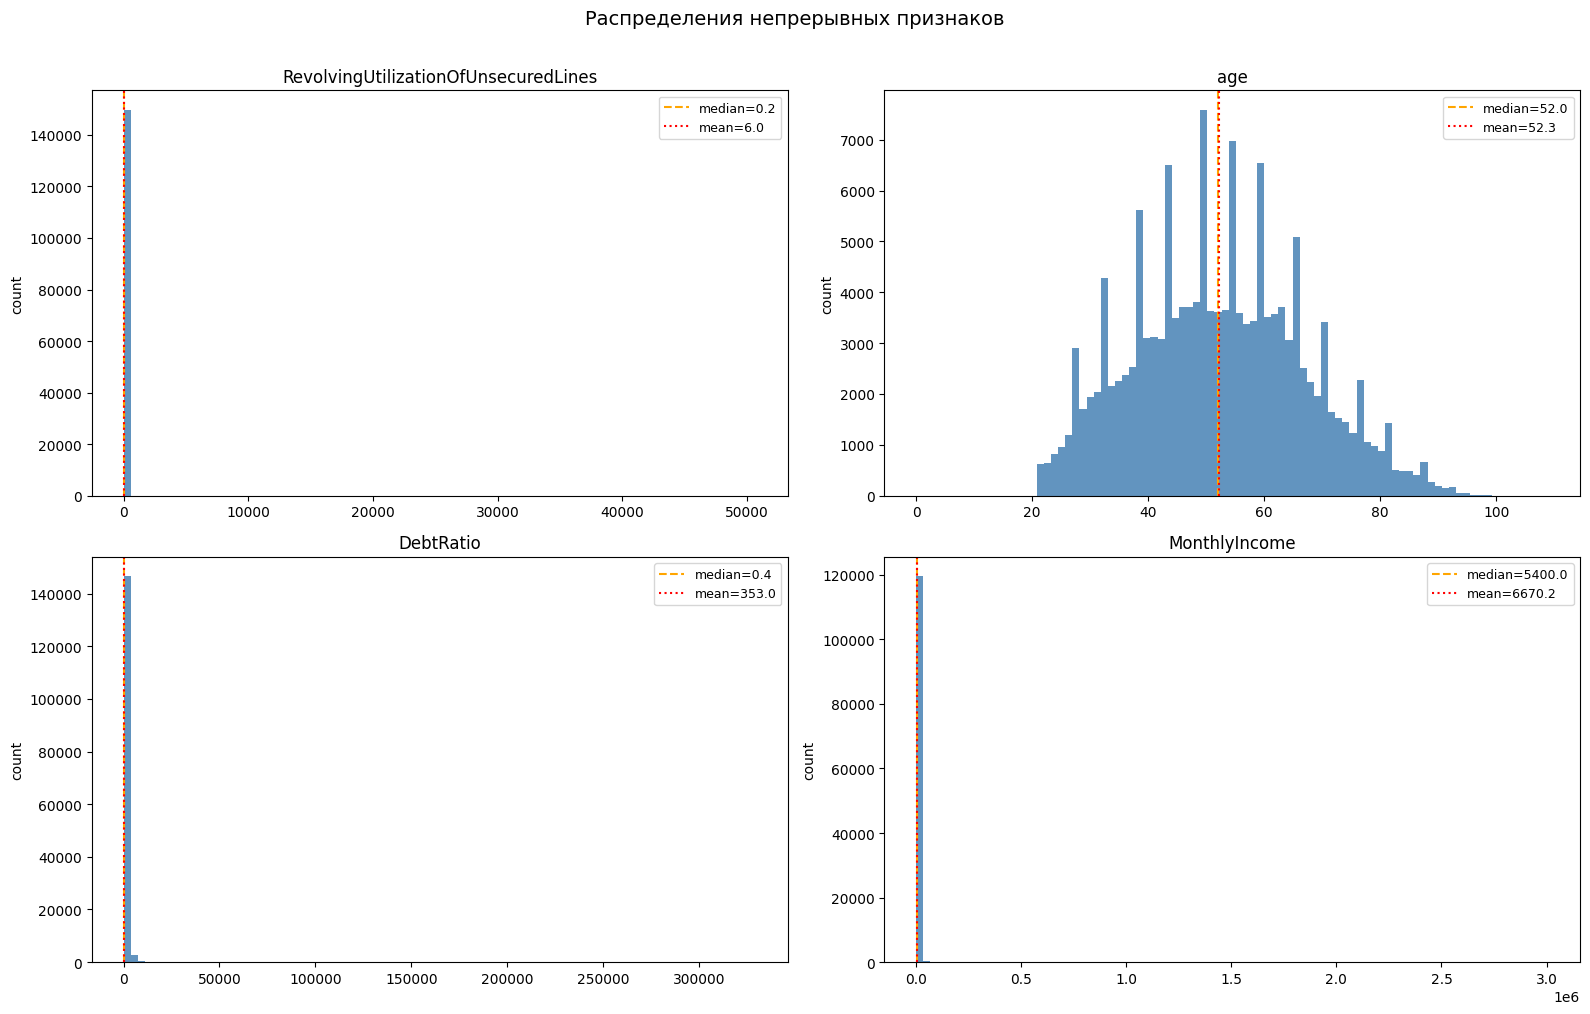

In [11]:
# --- Распределения числовых признаков ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()

    ax.hist(data, bins=89, color='steelblue', edgecolor='none', alpha=0.85)

    # Медиана и среднее
    ax.axvline(data.median(), color='orange', lw=1.5, linestyle='--', label=f'median={data.median():.1f}')
    ax.axvline(data.mean(),   color='red',    lw=1.5, linestyle=':',  label=f'mean={data.mean():.1f}')

    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)

plt.suptitle('Распределения непрерывных признаков', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Переведем "плохие" распределения на логарифмическую шкалу.

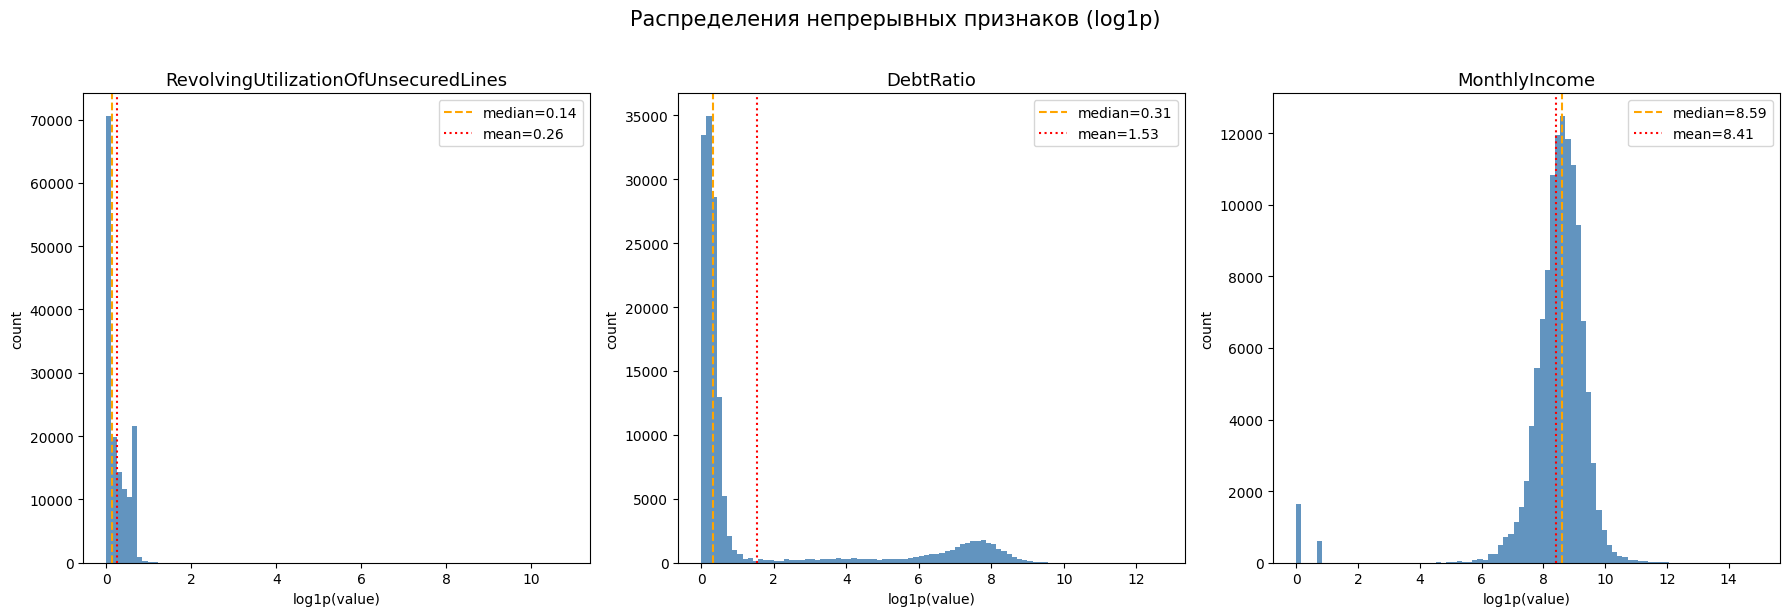

In [12]:

num_cols_filtered = [col for col in num_cols if col != 'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col in zip(axes, num_cols_filtered):
    data = np.log1p(df[col].dropna())
    
    ax.hist(data, bins=89, color='steelblue', edgecolor='none', alpha=0.85)
    ax.axvline(data.median(), color='orange', lw=1.5, linestyle='--', 
               label=f'median={data.median():.2f}')
    ax.axvline(data.mean(), color='red', lw=1.5, linestyle=':', 
               label=f'mean={data.mean():.2f}')
    
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('log1p(value)')
    ax.set_ylabel('count')
    ax.legend(fontsize=10)

plt.suptitle('Распределения непрерывных признаков (log1p)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

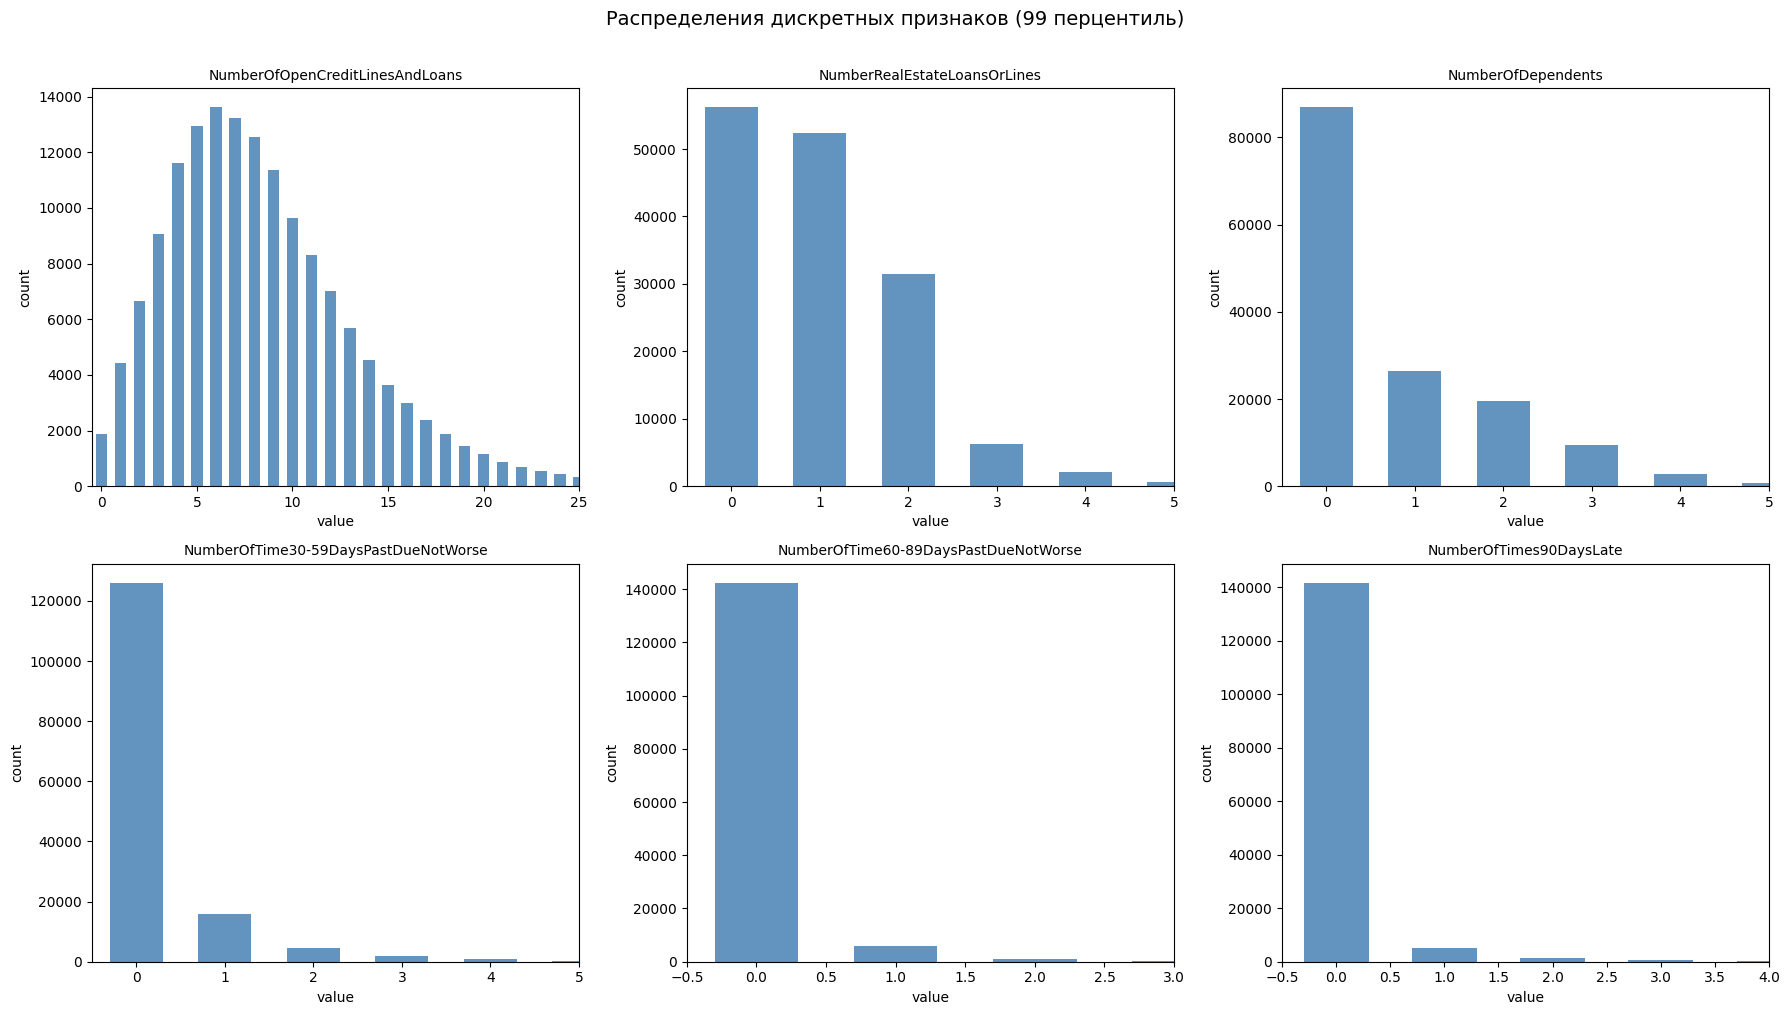

In [13]:
# --- Распределения дискретных счётных признаков ---

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    ax = axes[i]
    data = df[col].dropna()
    vc = data.value_counts().sort_index()

    ax.bar(vc.index, vc.values, color='steelblue', alpha=0.85, width=0.6)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('value')
    ax.set_ylabel('count')

    p99 = data.quantile(0.99)
    if data.max() > p99 * 2:
        ax.set_xlim(-0.5, p99 + 1)

plt.suptitle('Распределения дискретных признаков (99 перцентиль)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Корреляции

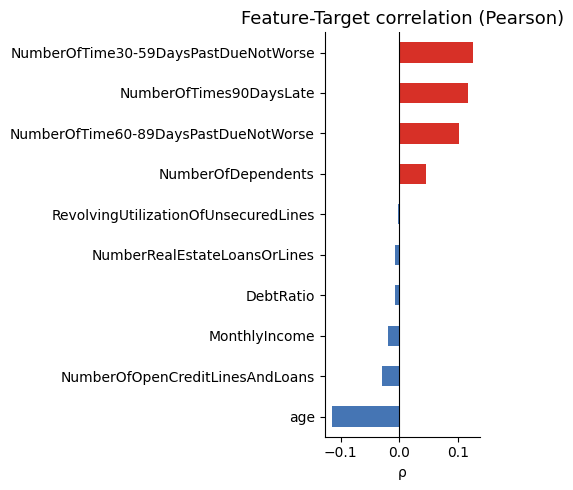

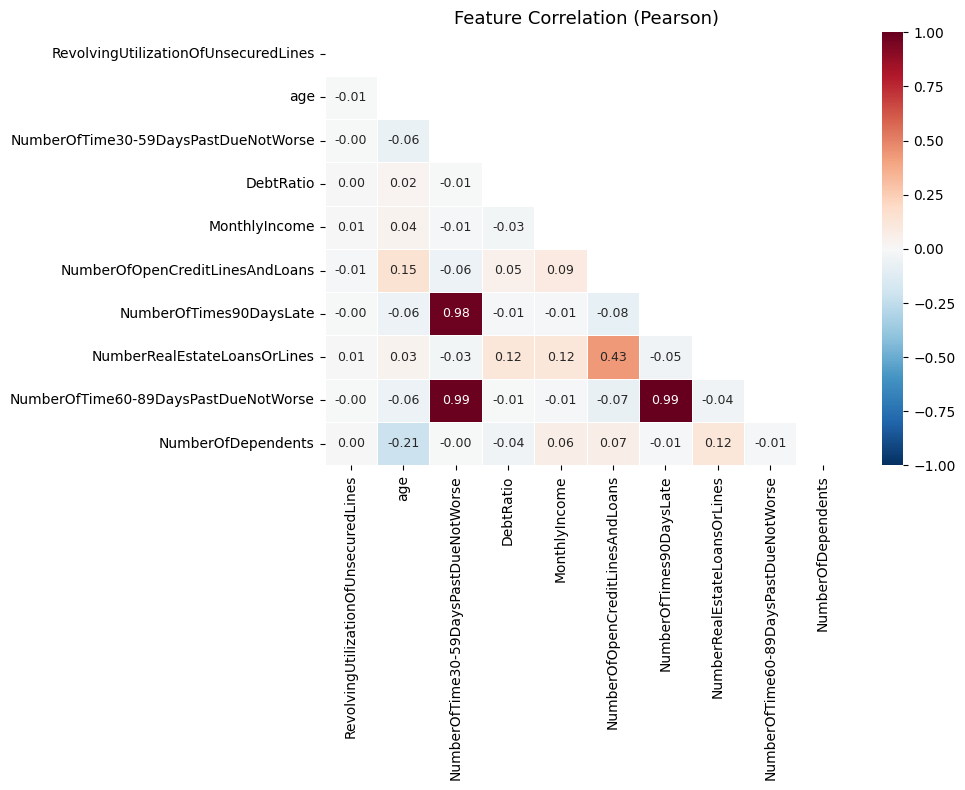

In [14]:
# ── Корреляция каждого признака с таргетом ──────────────────────────────
target = 'SeriousDlqin2yrs'
features = [c for c in df.columns if c != target]

corr_with_target = (
    df[features + [target]]
    .corr(method='pearson')[target]
    .drop(target)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature-Target correlation (Pearson)', fontsize=13)
ax.set_xlabel('ρ')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# ── Корреляционная матрица признаков между собой ────────────────────────
corr_matrix = df[features].corr(method='pearson')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # верхний треугольник — дубль

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

Видим сильную корреляцию признаков NumberOfTime.. (количества просрочек в прошлом)

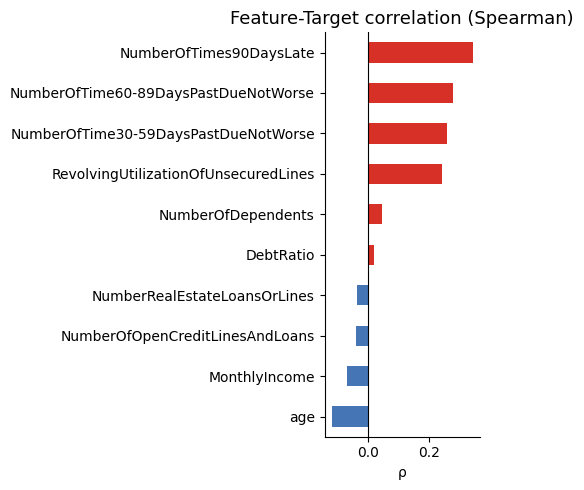

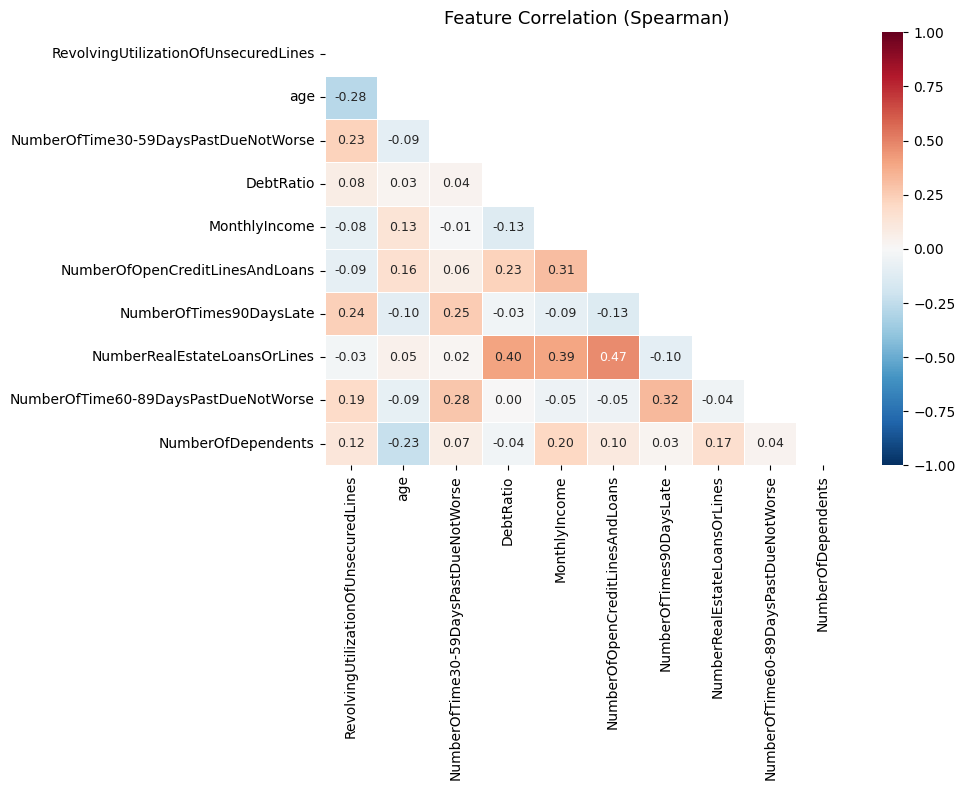

In [15]:
# ── Корреляция каждого признака с таргетом ──────────────────────────────
target = 'SeriousDlqin2yrs'
features = [c for c in df.columns if c != target]

# Spearman — устойчивее к выбросам и нелинейности, чем Pearson
corr_with_target = (
    df[features + [target]]
    .corr(method='spearman')[target]
    .drop(target)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature-Target correlation (Spearman)', fontsize=13)
ax.set_xlabel('ρ')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

# ── Корреляционная матрица признаков между собой ────────────────────────
corr_matrix = df[features].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # верхний треугольник — дубль

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Feature Correlation (Spearman)', fontsize=13)
plt.tight_layout()
plt.show()

- По корреляции Спирмана такой сильной зависимости нет. Возможно, дело в выбросах (значения 96, 98 в этих признаках), которые тащат корреляцию Пирсона к единице, а реальная их связь - умеренная (0.25 - 0.32).
- Зависимость таргета с признаками у Пирсона ниже. Скорее всего из-за скошенных влево распределений.

Следовательно, корреляция Спирмана на этих данных показывает более надежные значения.  
Ожидаемо в обоих случаях прошлые просрочки коррелируют с таргетом больше всего. А самая сильная обратная зависимость с таргетом - возраст.

## Гипотеза 1: age

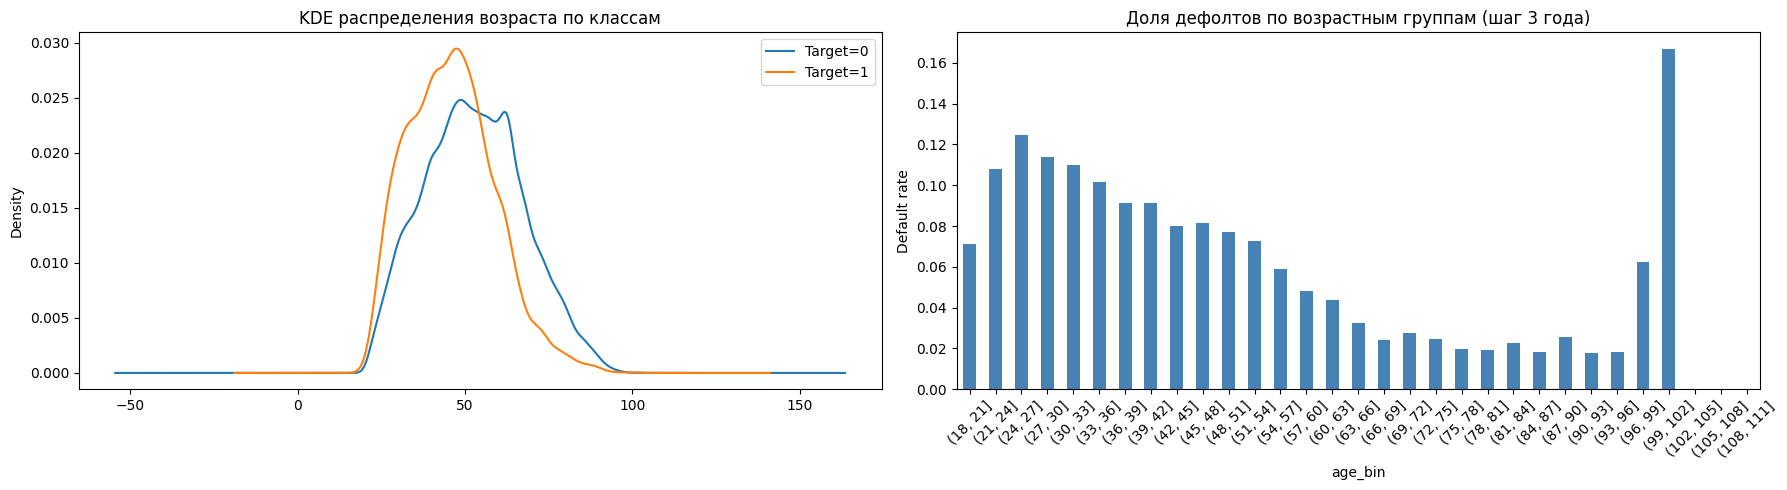

In [16]:
import scipy
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# KDE по классам
for label, grp in df.groupby('SeriousDlqin2yrs'):
    grp['age'].plot.kde(ax=axes[0], label=f'Target={label}')
axes[0].set_title('KDE распределения возраста по классам')
axes[0].legend()

# Default rate по возрастным бинам
df['age_bin'] = pd.cut(df['age'], bins=range(0, 115, 3))
rate = df.groupby('age_bin')['SeriousDlqin2yrs'].mean()
rate.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Доля дефолтов по возрастным группам (шаг 3 года)')
axes[1].set_ylabel('Default rate')
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()

Риск дефолта растет, достигая локального максимума у заемщиков возрастом 24-27 лет, после чего видим плавное снижение. С 96 лет резкий скачок до глобального пика - возможно, выборка на таких возрастах слишком мала и не репрезентативна. Проверим это. 

In [17]:
young = df[df['age'] < 18]
print(f"Записей age < 18: {len(young)}")
print(young['age'].value_counts().sort_index())


old = df[df['age'] > 96]
print(f"\nЗаписей age > 96: {len(old)}")
print(old['age'].value_counts().sort_index())


print("\n--- age > 96: детали ---")
print(df[df['age'] > 96].groupby('age')['SeriousDlqin2yrs']
      .agg(count='count', default_rate='mean')
      .round(3))

Записей age < 18: 1
age
0    1
Name: count, dtype: int64

Записей age > 96: 45
age
97     17
98      6
99      9
101     3
102     3
103     3
105     1
107     1
109     2
Name: count, dtype: int64

--- age > 96: детали ---
     count  default_rate
age                     
97      17         0.000
98       6         0.000
99       9         0.222
101      3         0.333
102      3         0.000
103      3         0.000
105      1         0.000
107      1         0.000
109      2         0.000


При count = 3 есть одно наблюдение с дефолтом, что дает +0.3 default_rate. Можно считать, что
### Гипотеза 1 подтверждена частично:
риск дефолта снижается при увеличении возраста, но только начиная с ~24 лет.

In [18]:
df[df['age'] == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_bin
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0,NaN


## Гипотеза 2: MonthlyIncome

In [19]:
df.MonthlyIncome.describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [20]:
print('missing:')
print(f'{df["MonthlyIncome"].isnull().sum()} rows')

print(f'{(df["MonthlyIncome"].isnull().sum() / len(df) * 100).round(2)}%')

missing:
29731 rows
19.82%


In [21]:
df['MonthlyIncome'].nunique()

13594

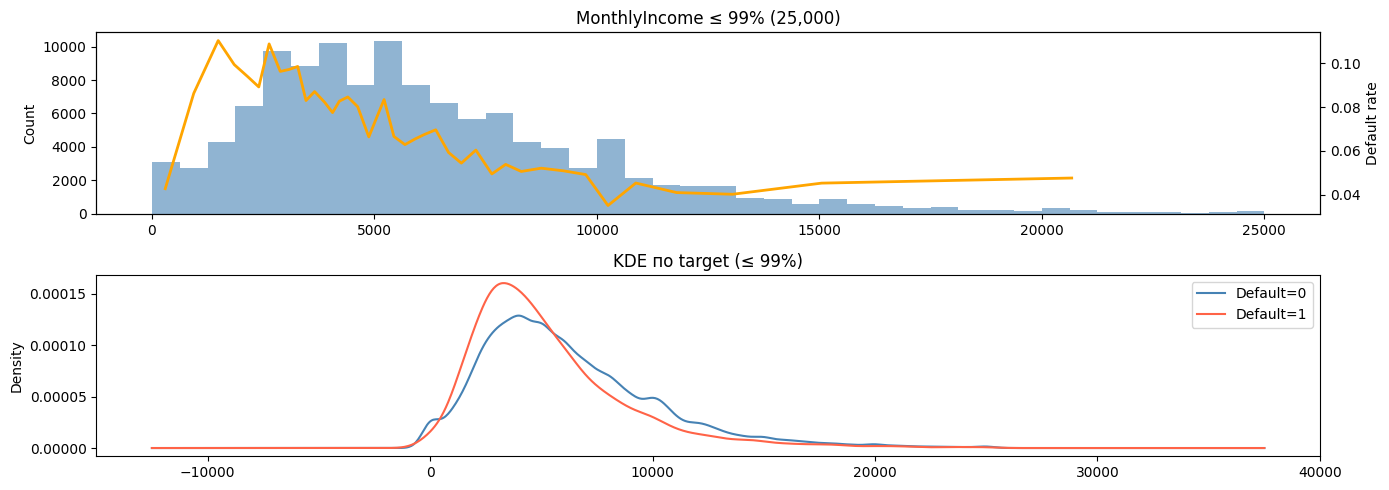

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
q99 = df['MonthlyIncome'].quantile(0.99)
data = df[df['MonthlyIncome'] <= q99]

# гистограмма + default rate
ax1 = axes[0]
ax2 = ax1.twinx()

data['MonthlyIncome'].plot.hist(bins=40, ax=ax1, color='steelblue', alpha=0.6)
data['income_bin'] = pd.qcut(data['MonthlyIncome'], q=40, duplicates='drop')
rate = data.groupby('income_bin')['SeriousDlqin2yrs'].mean()
bin_centers = [iv.mid for iv in rate.index]
ax2.plot(bin_centers, rate.values, color='orange', linewidth=2)

ax1.set_title(f'MonthlyIncome ≤ 99% ({q99:,.0f})')
ax1.set_ylabel('Count')
ax2.set_ylabel('Default rate', color='black')
ax2.tick_params(axis='y', colors='black')

# KDE по target
for label, color in zip([0, 1], ['steelblue', 'tomato']):
    data[data['SeriousDlqin2yrs'] == label]['MonthlyIncome'].plot.kde(ax=axes[1], label=f'Default={label}', color=color)
axes[1].set_title('KDE по target (≤ 99%)')
axes[1].legend()

plt.tight_layout()
plt.show()

Пики распределений в самой плотной зоне. При этом "плохие" заемщики концентрируются слегка левее. Распределение "хороших" заемщиков более широкое и хвост вправо убывает заметно медленнее.
По первому графику видим, что начиная с Income ~= 1000 риск дефолта снижается, однако до ~1000 риск ниже.
### Гипотеза 2 частично подтверждена

## Гипотеза 3: MonthlyIncome NaNs

Посмотрим, выделяются ли чем-то заемщики с пропуском в MonthlyIncome по другим признакам.

In [23]:
df['income_missing'] = df['MonthlyIncome'].isna().astype(int)

In [24]:
df.groupby('income_missing')[['age', 'DebtRatio', 'NumberOfDependents',
    'RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate']].mean()

,age,DebtRatio,NumberOfDependents,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate
income_missing,,,,,
0,51.289792,26.598777,0.851832,5.899873,0.211925
1,56.362349,1673.396556,0.316310,6.649421,0.484612


In [25]:
print(df.groupby('income_missing')['DebtRatio'].describe())

                   count         mean          std  min         25%  \
income_missing                                                        
0               120269.0    26.598777   424.446457  0.0    0.143388   
1                29731.0  1673.396556  4248.372895  0.0  123.000000   

                        50%          75%       max  
income_missing                                      
0                  0.296023     0.482559   61106.5  
1               1159.000000  2382.000000  329664.0  


In [26]:
q99_dr = df['DebtRatio'].quantile(0.99)
q99_dr

np.float64(4979.040000000037)

Видим, что DebtRatio (соотн. долговой нагрузки к доходу) у заемщиков с пропуском в доходе кратно выше.

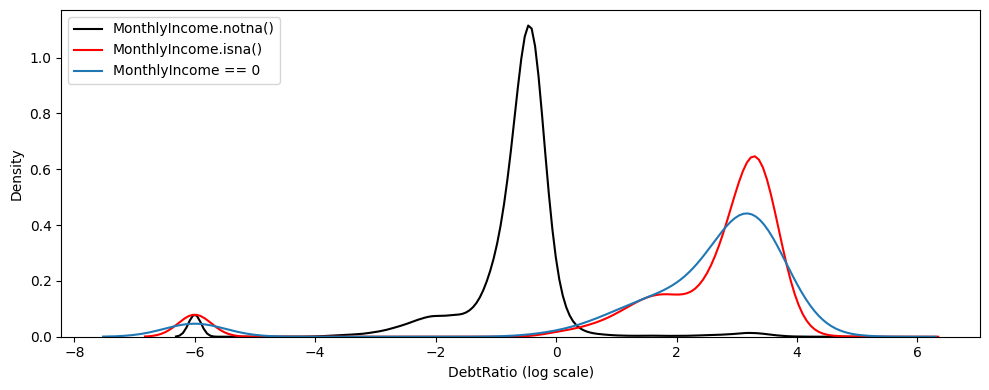

In [27]:
epsilon = 1e-6
x_notna = df[df['MonthlyIncome'].notna()]['DebtRatio'].values
x_isna  = df[df['MonthlyIncome'].isna()]['DebtRatio'].values
x_zero  = df[df['MonthlyIncome'] == 0]['DebtRatio'].values

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(x=np.log10(x_notna + epsilon), ax=ax, color='black', label='MonthlyIncome.notna()')
sns.kdeplot(x=np.log10(x_isna  + epsilon), ax=ax, color='red',   label='MonthlyIncome.isna()')
sns.kdeplot(x=np.log10(x_zero  + epsilon), ax=ax,                label='MonthlyIncome == 0')


ax.legend(loc='upper left')
ax.set_xlabel('DebtRatio (log scale)')
plt.tight_layout()
plt.show()

DebtRatio для пропусков распределен почти также, как для нулей.

Высокий DebtRatio у заемщиков с пропусками и нулями в доходе - это, вероятно, артефакт вычисления. Если MonthlyIncome = 0 или =NaN, то DebtRatio = долг/0 или просто заполнен произвольно. 

In [28]:
missing_income = df['MonthlyIncome'].isna() | (df['MonthlyIncome'] == 0)

# Количество строк с missing_income в диапазоне DebtRatio от 0 до 1
in_range = (df['DebtRatio'] >= 0) & (df['DebtRatio'] <= 1)
total_in_range = in_range.sum()
missing_in_range = (in_range & missing_income).sum()
print(f"% of MonthlyIncome =0 or NaN for 0 <= DebtRatio <= 1: {missing_in_range / total_in_range * 100:.2f}% ({missing_in_range}/{total_in_range})")

# Остальные пороги
thresholds = [2, 5, 10, 50, 100, 300, 500]
for t in thresholds:
    total_low = (df['DebtRatio'] > t).sum()
    missing_low = ((df['DebtRatio'] > t) & missing_income).sum()
    percentage = (missing_low / total_low * 100) if total_low > 0 else 0
    print(f"% of MonthlyIncome =0 or NaN for DebtRatio > {t}: {percentage:.2f}% ({missing_low}/{total_low})")

% of MonthlyIncome =0 or NaN for 0 <= DebtRatio <= 1: 1.69% (1940/114863)
% of MonthlyIncome =0 or NaN for DebtRatio > 2: 94.25% (29259/31045)
% of MonthlyIncome =0 or NaN for DebtRatio > 5: 97.09% (28784/29646)
% of MonthlyIncome =0 or NaN for DebtRatio > 10: 97.72% (28218/28877)
% of MonthlyIncome =0 or NaN for DebtRatio > 50: 98.05% (25428/25934)
% of MonthlyIncome =0 or NaN for DebtRatio > 100: 98.08% (23912/24380)
% of MonthlyIncome =0 or NaN for DebtRatio > 300: 98.25% (21877/22266)
% of MonthlyIncome =0 or NaN for DebtRatio > 500: 98.45% (20283/20602)


Уже с DebtRatio>2 пропуск или 0 в доходе у 94% клиентов

In [29]:
has_income = df[df['MonthlyIncome'] > 0].copy()
no_income  = df[df['MonthlyIncome'].isna() | (df['MonthlyIncome'] == 0)].copy()

# Предполагаемый абсолютный долг у тех, у кого доход известен
has_income['abs_debt'] = has_income['DebtRatio'] * has_income['MonthlyIncome']

print("=== Абсолютный долг (DebtRatio × Income), группа с доходом ===")
print(has_income['abs_debt'].describe(percentiles=[.25,.5,.75,.9,.99]))

print("\n=== DebtRatio группы БЕЗ дохода (гипотеза: это и есть абсолютный долг) ===")
print(no_income['DebtRatio'].describe(percentiles=[.25,.5,.75,.9,.99]))

=== Абсолютный долг (DebtRatio × Income), группа с доходом ===
count    118635.000000
mean       2146.917475
std        4217.981199
min           0.000000
25%         632.632563
50%        1649.678988
75%        2900.401406
90%        4396.501359
99%        9423.312653
max      478450.559160
Name: abs_debt, dtype: float64

=== DebtRatio группы БЕЗ дохода (гипотеза: это и есть абсолютный долг) ===
count     31365.000000
mean       1668.195823
std        4185.968629
min           0.000000
25%         122.000000
50%        1144.000000
75%        2373.000000
90%        3773.200000
99%        8174.080000
max      329664.000000
Name: DebtRatio, dtype: float64


Доля DebtRatio в [0,2] при наличии дохода:  0.9849454208285919
Доля DebtRatio в [0,2] при отсутствии дохода: 0.06714490674318507


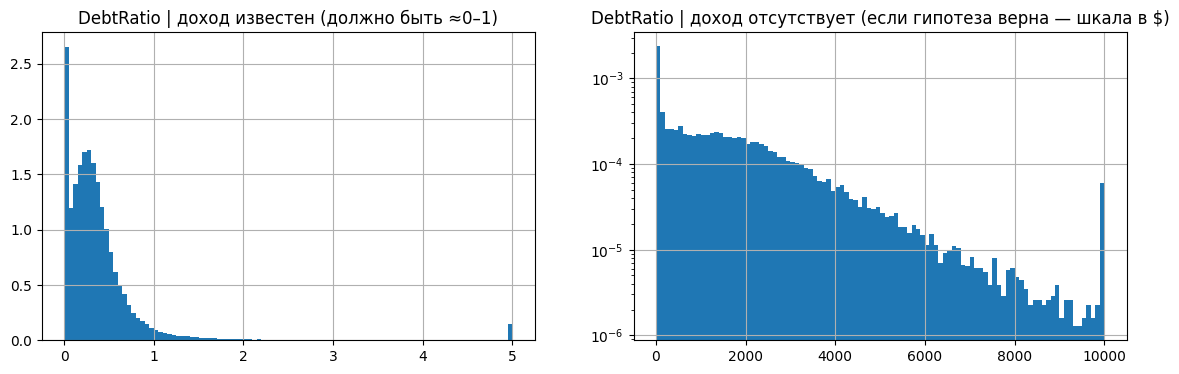

In [30]:
# Распределение самого DebtRatio в обеих группах
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

has_income['DebtRatio'].clip(0, 5).hist(bins=100, ax=axes[0], density=True)
axes[0].set_title('DebtRatio | доход известен (должно быть ≈0–1)')

no_income['DebtRatio'].clip(0, 10000).hist(bins=100, ax=axes[1], density=True, log=True)
axes[1].set_title('DebtRatio | доход отсутствует (если гипотеза верна — шкала в $)')

# Процент "нормальных" значений (0–2) в каждой группе
print("Доля DebtRatio в [0,2] при наличии дохода: ",
      (has_income['DebtRatio'].between(0, 2)).mean())
print("Доля DebtRatio в [0,2] при отсутствии дохода:",
      (no_income['DebtRatio'].between(0, 2)).mean())

In [31]:
# Создаем флаги
# debtratio_double_semantics: 1 если DebtRatio > 10, иначе 0
df['debtratio_double_semantics'] = (df['DebtRatio'] > 10).astype(int)

# income_zero_or_nan: 1 если MonthlyIncome == 0 или NaN, иначе 0
df['income_zero_or_nan'] = (df['MonthlyIncome'].isna() | (df['MonthlyIncome'] == 0)).astype(int)

# Процент строк, где флаги одинаковы (оба 0 или оба 1)
same_flags = (df['debtratio_double_semantics'] == df['income_zero_or_nan']).sum()
total_rows = len(df)
percentage_same = same_flags / total_rows * 100

print(f"Процент строк с одинаковыми флагами: {percentage_same:.2f}% ({same_flags}/{total_rows})")

# correlation between the two flags
correlation = df['debtratio_double_semantics'].corr(df['income_zero_or_nan'])
print(f"Корреляция Пирсона между flaгами: {correlation:.6f}")

# Дополнительно: таблица совпадений
print("\nТаблица совпадений флагов:")
pd.crosstab(df['debtratio_double_semantics'], df['income_zero_or_nan'], 
            rownames=['debtratio_double_semantics'], 
            colnames=['income_zero_or_nan'])

Процент строк с одинаковыми флагами: 97.46% (146194/150000)
Корреляция Пирсона между flaгами: 0.922212

Таблица совпадений флагов:


income_zero_or_nan,0,1
debtratio_double_semantics,,
0,117976,3147
1,659,28218


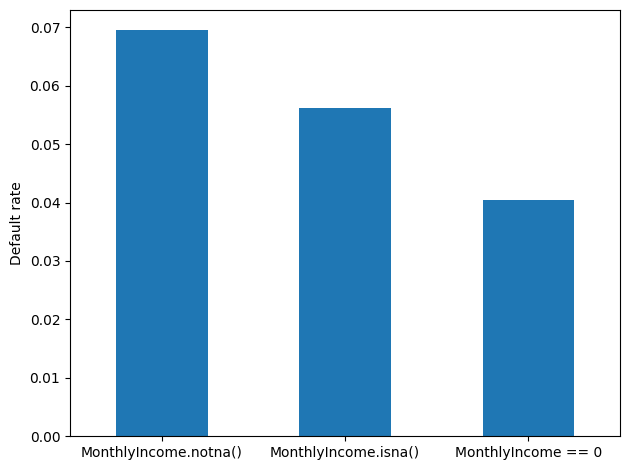

In [32]:
groups = {
    'MonthlyIncome.notna()': df[df['MonthlyIncome'].notna()],
    'MonthlyIncome.isna()':  df[df['MonthlyIncome'].isna()],
    'MonthlyIncome == 0':    df[df['MonthlyIncome'] == 0],
}

rates = {k: v['SeriousDlqin2yrs'].mean() for k, v in groups.items()}
pd.Series(rates).plot.bar()
plt.xticks(rotation=0)
plt.ylabel('Default rate')
plt.tight_layout()
plt.show()

### Гипотеза 3 не подтверждена

## Гипотеза 4. MonthlyIncome, NumberOfDependents

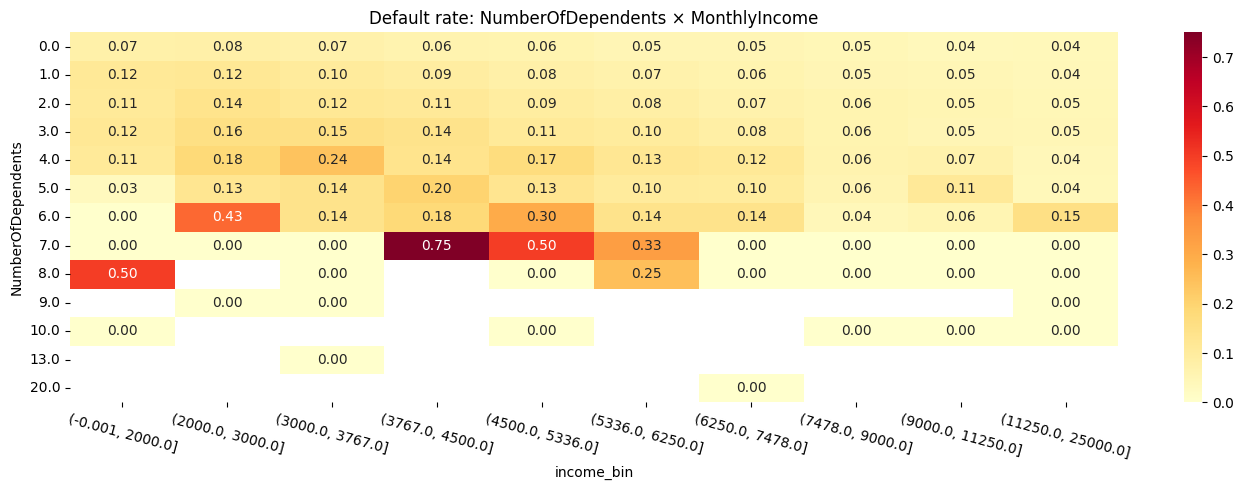

In [33]:
data = df[df['MonthlyIncome'] <= df['MonthlyIncome'].quantile(0.99)].copy()
data['income_bin'] = pd.qcut(data['MonthlyIncome'], q=10, duplicates='drop')

pivot = data.groupby(['NumberOfDependents', 'income_bin'])['SeriousDlqin2yrs'].mean().unstack()

plt.figure(figsize=(14, 5))
ax = sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
ax.set_title('Default rate: NumberOfDependents × MonthlyIncome')
plt.xticks(rotation=-15)  # Подписи под углом 45°
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Слева направо (столбцы): группы по доходам, от самых низких до высоких  
Сверху вниз: количество иждивенцев  
Значения: вероятность дефолта  

Видна закономерность: при высоком доходе количество иждивенцев почти не влияет.  
При доходе ниже медианы риск растет с ростом числа иждивенцев. (на группах с достаточным количеством данных)

### Гипотеза 4 подтверждена

## Гипотеза 6

Существует ли "перегрузка" от большого количества кредитов: значение NumberOfOpenCreditLinesAndLoans, после которого вероятность дефолта сильно возрастает?  
Ищем U-образную или J-образную зависимость: сначала риск падает (много кредитов = надежный заемщик с историей), потом растет.

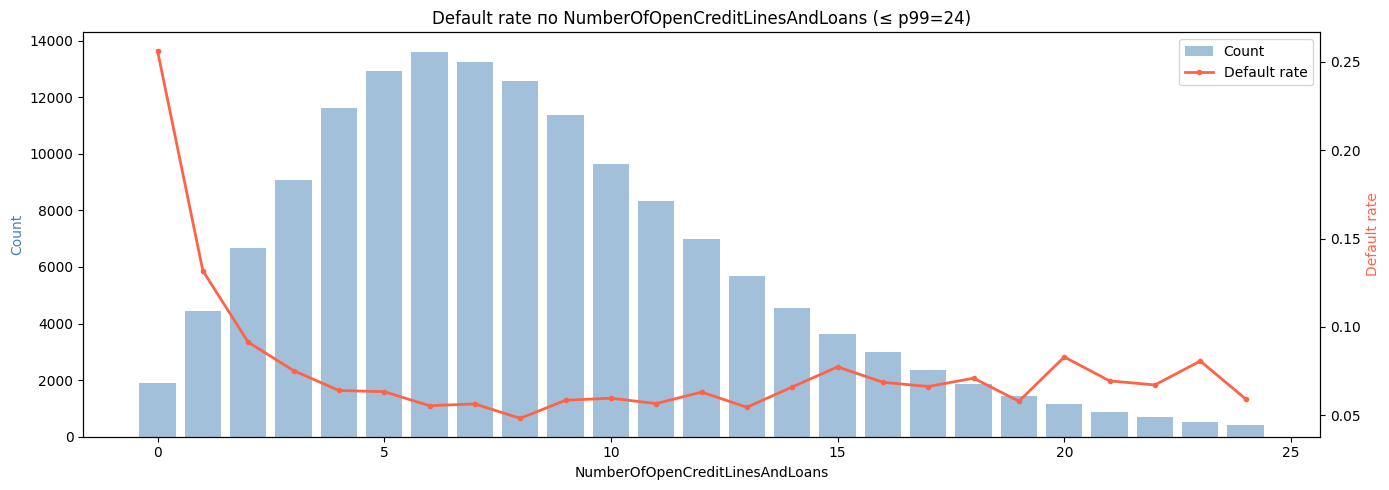

In [34]:
col = 'NumberOfOpenCreditLinesAndLoans'
p99 = df[col].quantile(0.99)
data = df[df[col] <= p99]

agg = data.groupby(col)['SeriousDlqin2yrs'].agg(count='count', rate='mean').reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(agg[col], agg['count'], color='steelblue', alpha=0.5, label='Count')
ax2.plot(agg[col], agg['rate'], color='tomato', linewidth=2, marker='o', markersize=3, label='Default rate')

ax1.set_xlabel(col)
ax1.set_ylabel('Count', color='steelblue')
ax2.set_ylabel('Default rate', color='tomato')
ax1.set_title(f'Default rate по {col} (≤ p99={p99:.0f})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

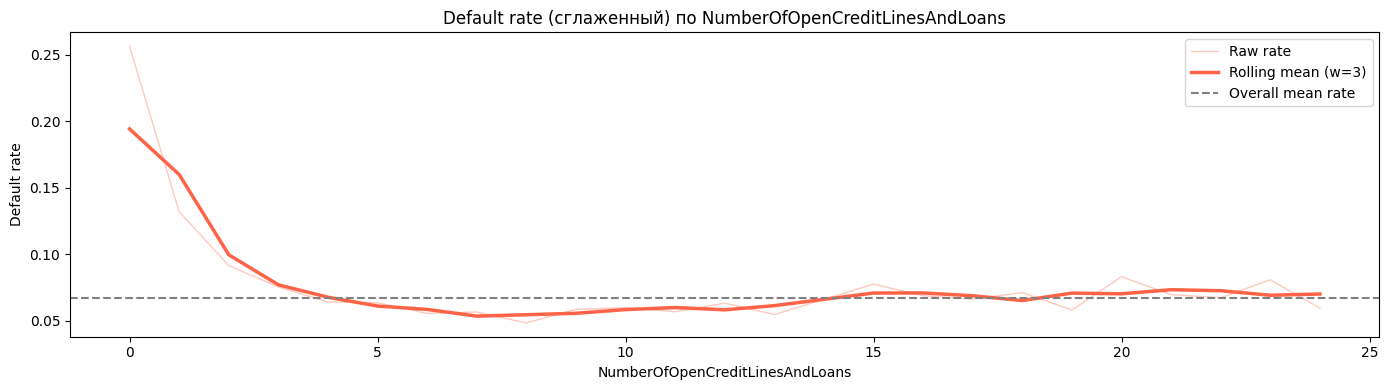

In [35]:
agg['rate_smooth'] = agg['rate'].rolling(window=3, center=True, min_periods=1).mean()

plt.figure(figsize=(14, 4))
plt.plot(agg[col], agg['rate'], color='tomato', alpha=0.35, linewidth=1, label='Raw rate')
plt.plot(agg[col], agg['rate_smooth'], color='tomato', linewidth=2.5, label='Rolling mean (w=3)')
plt.axhline(df['SeriousDlqin2yrs'].mean(), color='gray', linestyle='--', label='Overall mean rate')
plt.xlabel(col)
plt.ylabel('Default rate')
plt.title('Default rate (сглаженный) по NumberOfOpenCreditLinesAndLoans')
plt.legend()
plt.tight_layout()
plt.show()

Видим явную тенденцию в начале: риск дефолта высокий (около 25%) при 0 открытых линий и спадает до 6% при 5 открытых линиях.  
Плато минимального риска с 5 до ~12 линий.  
После 12 линий риск слегка увеличивается, но разница порядка 2-3%. Скользящее среднее закрепляется выше общего среднего, однако по первому графику видим сильное уменьшение размера выборки в той же точке, что увеличивает разброс и делает среднее значение ненадежным. 


### Гипотеза 6 подтверждена частично

## Гипотеза 5

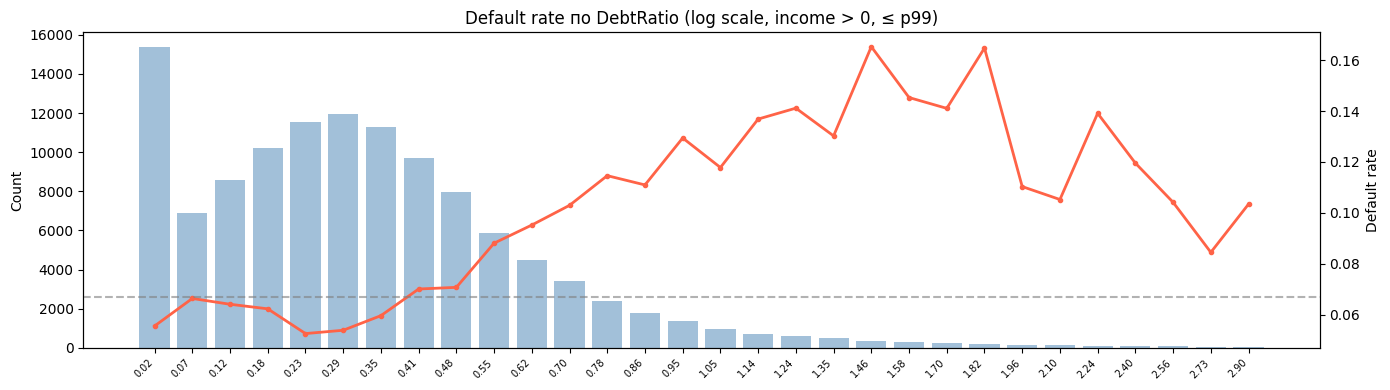

In [36]:
col = 'DebtRatio'
data = df[(df['income_missing'] == 0) & (df['MonthlyIncome'] > 0)].copy()
p99 = data[col].quantile(0.99)
data = data[data[col] <= p99].copy()

import numpy as np
data['log_dr'] = np.log1p(data[col])

data['bin'] = pd.cut(data['log_dr'], bins=30)
agg = data.groupby('bin', observed=True)['SeriousDlqin2yrs'].agg(count='count', rate='mean')
centers = [iv.mid for iv in agg.index]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(range(len(agg)), agg['count'], color='steelblue', alpha=0.5)
ax2.plot(range(len(agg)), agg['rate'], color='tomato', linewidth=2, marker='o', markersize=3)
ax2.axhline(df['SeriousDlqin2yrs'].mean(), color='gray', linestyle='--', alpha=0.6)

# Подписи в исходном масштабе
orig_labels = [f'{np.expm1(c):.2f}' for c in centers]
ax1.set_xticks(range(len(agg)))
ax1.set_xticklabels(orig_labels, rotation=45, ha='right', fontsize=7)
ax1.set_title('Default rate по DebtRatio (log scale, income > 0, ≤ p99)')
ax1.set_ylabel('Count'); ax2.set_ylabel('Default rate')
plt.tight_layout(); plt.show()

Риск начинает расти от значения DebtRate>0.5, а левее монотонной зависимости нет.
### Гипотеза 5.2 опровергнута

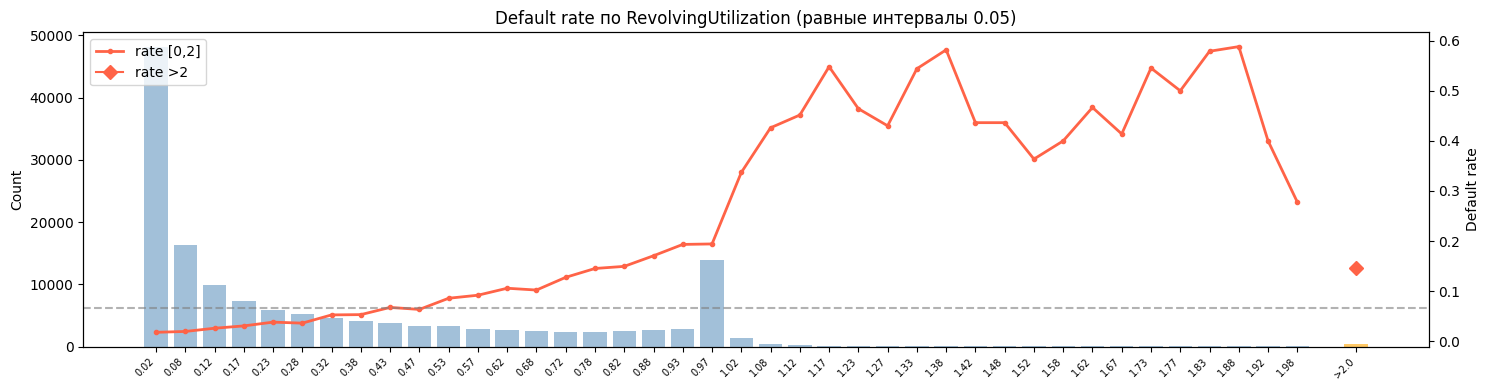

In [37]:
col = 'RevolvingUtilizationOfUnsecuredLines'
data_main = df[df[col] <= 2.0].copy()

# Равные интервалы по 0.05 до 2.0
data_main['bin'] = pd.cut(data_main[col], bins=np.arange(0, 2.05, 0.05), include_lowest=True)
agg = data_main.groupby('bin', observed=True)['SeriousDlqin2yrs'].agg(count='count', rate='mean')
centers = [iv.mid for iv in agg.index]

rate_over = df[df[col] > 2.0]['SeriousDlqin2yrs'].mean()
count_over = (df[col] > 2.0).sum()

fig, ax1 = plt.subplots(figsize=(15, 4))
ax2 = ax1.twinx()

x = list(range(len(agg)))
ax1.bar(x, agg['count'], color='steelblue', alpha=0.5)
ax2.plot(x, agg['rate'], color='tomato', linewidth=2, marker='o', markersize=3, label='rate [0,2]')

x_over = len(agg) + 1
ax1.bar(x_over, count_over, color='orange', alpha=0.6)
ax2.plot(x_over, rate_over, color='tomato', marker='D', markersize=7, label='rate >2')

ax1.set_xticks(x + [x_over])
ax1.set_xticklabels([f'{c:.2f}' for c in centers] + ['>2.0'], rotation=45, ha='right', fontsize=7)
ax2.axhline(df['SeriousDlqin2yrs'].mean(), color='gray', linestyle='--', alpha=0.6)
ax1.set_title('Default rate по RevolvingUtilization (равные интервалы 0.05)')
ax1.set_ylabel('Count'); ax2.set_ylabel('Default rate')
ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [38]:
print((df['RevolvingUtilizationOfUnsecuredLines'] > 1).mean())
print((df['RevolvingUtilizationOfUnsecuredLines'] > 100).mean())
df['RevolvingUtilizationOfUnsecuredLines'].quantile([0.5, 0.9, 0.95, 0.99])

0.02214
0.0014866666666666667


0.50    0.154181
0.90    0.981278
0.95    1.000000
0.99    1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [39]:
print(f'lower than 100%: {df["RevolvingUtilizationOfUnsecuredLines"].lt(1).sum()}')
print(f'greater than 100%: {df["RevolvingUtilizationOfUnsecuredLines"].gt(1).sum()}')
print(f'greater than 200%: {df["RevolvingUtilizationOfUnsecuredLines"].gt(2).sum()}')

lower than 100%: 146662
greater than 100%: 3321
greater than 200%: 371


In [40]:
df[df["RevolvingUtilizationOfUnsecuredLines"].gt(1)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_bin,income_missing,debtratio_double_semantics,income_zero_or_nan
163,1,1.046279,47,1,1.104301,5416.0,6,0,2,0,1.0,"(45, 48]",0,0,0
192,0,1.095083,53,5,0.536704,3500.0,7,1,1,2,0.0,"(51, 54]",0,0,0
227,1,1.953488,38,0,0.153500,3556.0,5,0,0,0,2.0,"(36, 39]",0,0,0
252,1,1.048211,58,7,0.151957,3500.0,12,0,0,0,0.0,"(57, 60]",0,0,0
294,0,2340.000000,45,0,0.339333,8333.0,7,0,2,0,2.0,"(42, 45]",0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149940,0,1.049900,26,0,0.073220,6500.0,6,0,0,1,0.0,"(24, 27]",0,0,0
149956,1,1.135552,41,2,0.845887,7500.0,12,0,4,1,0.0,"(39, 42]",0,0,0
149963,0,1.005733,48,0,0.248896,2944.0,4,3,0,0,1.0,"(45, 48]",0,0,0
149965,0,1.010934,63,0,0.608211,6015.0,8,0,1,0,0.0,"(60, 63]",0,0,0


In [41]:
df[df["RevolvingUtilizationOfUnsecuredLines"].gt(2)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_bin,income_missing,debtratio_double_semantics,income_zero_or_nan
294,0,2340.000000,45,0,0.339333,8333.0,7,0,2,0,2.0,"(42, 45]",0,0,0
698,1,2066.000000,58,0,0.271121,6000.0,8,1,1,0,1.0,"(57, 60]",0,0,0
901,0,2.258964,33,2,0.032484,2000.0,1,1,0,0,2.0,"(30, 33]",0,0,0
1992,1,1143.000000,44,2,0.547762,6500.0,13,0,4,0,2.0,"(42, 45]",0,0,0
2332,0,6324.000000,59,0,0.136673,11318.0,4,0,1,0,1.0,"(57, 60]",0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149103,0,6109.000000,43,0,0.229902,12500.0,9,0,2,0,0.0,"(42, 45]",0,0,0
149161,0,22000.000000,38,0,1.080020,3973.0,7,0,2,0,3.0,"(36, 39]",0,0,0
149246,0,771.000000,52,0,0.832021,8000.0,13,0,3,0,0.0,"(51, 54]",0,0,0
149280,0,20514.000000,42,0,0.062102,9902.0,1,1,0,0,2.0,"(39, 42]",0,0,0


3k значений с коэффициентом выше 1. Похоже на органичные значения при использовании кредитов сверх лимита.  
При RevUtil > 2 многие значения - это целые числа, т.е. в этих строках в RevUtil записаны какие-то другие данные.  
По графику видим почти монотонный рост риска дефолта на отрезке  RevUtil <= 1.0.  
На интервале (1, 2) риск сильно выше и разброс тоже: заемщики, превышающие кредитные лимиты имеют сильно больший риск дефолта.  

### Гипотеза 5.3 подтверждена

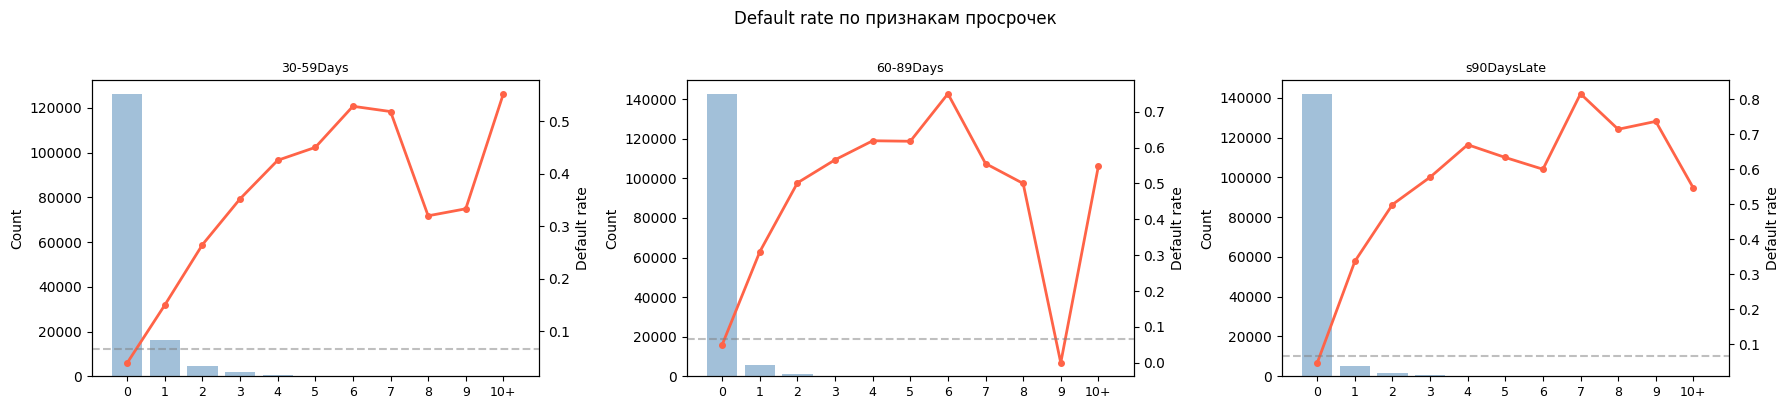

In [42]:
time_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, time_cols):
    s = df[col].copy()
    cap = 10  # всё >= 10 → группа "10+"
    s_capped = s.clip(upper=cap)
    s_capped = s_capped.map(lambda x: f'{int(cap)}+' if x == cap else str(int(x)))
    
    agg = df.copy()
    agg['_x'] = s_capped
    agg = agg.groupby('_x')['SeriousDlqin2yrs'].agg(count='count', rate='mean')
    
    # Сортируем правильно: числа по порядку, "10+" в конце
    order = [str(i) for i in range(cap)] + [f'{cap}+']
    agg = agg.reindex([o for o in order if o in agg.index])
    
    ax2 = ax.twinx()
    ax.bar(range(len(agg)), agg['count'], color='steelblue', alpha=0.5)
    ax2.plot(range(len(agg)), agg['rate'], color='tomato', linewidth=2, marker='o', markersize=4)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, fontsize=9)
    ax2.axhline(df['SeriousDlqin2yrs'].mean(), color='gray', linestyle='--', alpha=0.5)
    ax.set_title(col.replace('NumberOfTime', '').replace('PastDueNotWorse', ''), fontsize=9)
    ax.set_ylabel('Count'); ax2.set_ylabel('Default rate')

plt.suptitle('Default rate по признакам просрочек', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

In [43]:
outlier_mask = ((df['NumberOfTime30-59DaysPastDueNotWorse'] == 96) | 
                (df['NumberOfTime60-89DaysPastDueNotWorse'] ==96 ) | 
                (df['NumberOfTimes90DaysLate'] == 96))

df[outlier_mask]  
df[outlier_mask][['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']]

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
41945,96,96,96
69479,96,96,96
84168,96,96,96
94107,96,96,96
120050,96,96,96


In [44]:
outlier_mask = ((df['NumberOfTime30-59DaysPastDueNotWorse'] == 98) | 
                (df['NumberOfTime60-89DaysPastDueNotWorse'] ==98 ) | 
                (df['NumberOfTimes90DaysLate'] == 98))

df[outlier_mask]  
df[outlier_mask][['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']]  

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1734,98,98,98
2287,98,98,98
3885,98,98,98
4418,98,98,98
4706,98,98,98
...,...,...,...
147775,98,98,98
149154,98,98,98
149240,98,98,98
149440,98,98,98


### Гипотеза 5.4 подтверждена

269 строк со значениями 96/98

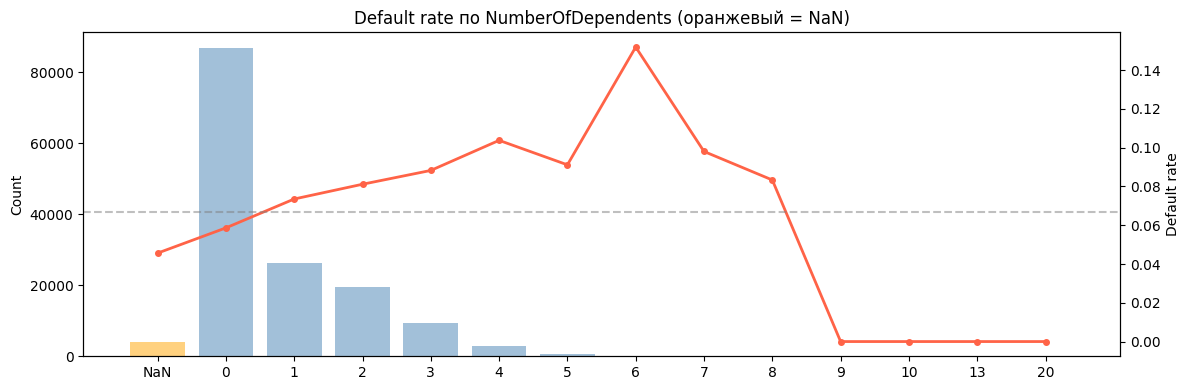

In [45]:
col = 'NumberOfDependents'
s = df[col].copy().fillna(-1)   # -1 = NaN-группа
agg = df.copy()
agg['_x'] = s
agg = agg.groupby('_x')['SeriousDlqin2yrs'].agg(count='count', rate='mean').reset_index()

labels = ['NaN' if x == -1 else str(int(x)) for x in agg['_x']]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
colors = ['orange' if l == 'NaN' else 'steelblue' for l in labels]
ax1.bar(range(len(agg)), agg['count'], color=colors, alpha=0.5)
ax2.plot(range(len(agg)), agg['rate'], color='tomato', linewidth=2, marker='o', markersize=4)
ax1.set_xticks(range(len(agg)))
ax1.set_xticklabels(labels)
ax2.axhline(df['SeriousDlqin2yrs'].mean(), color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Default rate по NumberOfDependents (оранжевый = NaN)')
ax1.set_ylabel('Count'); ax2.set_ylabel('Default rate')
plt.tight_layout(); plt.show()

In [46]:
df['NumberOfDependents'].quantile(0.99)

np.float64(4.0)

Больше иждивенцев - выше риск дефолта. Значения от 5 и более не дают репрезентативную оценку, т.к. выборка слишком мала.
### Гипотеза 5.1 подтверждена

# Выводы

### Общее

Сильный дисбаланс классов таргета: 93.3% - класс 0 vs 6.7% - класс 1.   
Есть пропуски: 19.82% значений в MonthlyIncome, 2.6% значений NumberOfDependents.  
Есть аномальные значения:
- DebtRatio (для MonthlyIncome =0 или =Nan),
- age < 21 (1 строка),
- RevolvingUtilizationOfUnsecuredLines > 2,
- NumberOfTime (значения 96 и 98)

Есть сильно скошенные влево распределения.

### Признаки

#### age
- Распределение близко к нормальному. 
- Одно аномальное значение с возрастом 0. На возрастах 96+ выборка очень мала (45 записей)
- Риск дефолта снижается с возрастом, начиная с ~24 лет

In [47]:
df['age'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min      0.0
max    109.0
50%     52.0
99%     87.0
Name: age, dtype: float64

#### RevolvingUtilizationOfUnsecuredLines

- Сильный предиктор дефолта. Риск монотонно растет на [0, 1]. Резко возрастает до ~50% при превышении кредитного лимита [1, 2]. 
- Значения 2+, вероятнее всего, представляют из себя ошибки в записи

In [48]:
df['RevolvingUtilizationOfUnsecuredLines'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min        0.000000
max    50708.000000
50%        0.154181
99%        1.092956
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

#### DebtRatio

- 94% строк с DebtRatio > 2 имеют 0 или пропуск в поле MonthlyIncome.
- DebtRatio заемщиков с пропуском или 0 в доходе заполняются абсолютным значением долговых обязательств, а не долг/доход. Это искажает распределение признака. Полезно вынести сумму долга в отдельный признак (вообще для всех заемщиков).

In [49]:
df['DebtRatio'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min         0.000000
max    329664.000000
50%         0.366508
99%      4979.040000
Name: DebtRatio, dtype: float64

#### MonthlyIncome

- 19.8% (29731) пропусков
- Коррелируют распределения NaN и нулей.

In [50]:
df['MonthlyIncome'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min          0.0
max    3008750.0
50%       5400.0
99%      25000.0
Name: MonthlyIncome, dtype: float64

#### NumberOfOpenCreditLinesAndLoans

- Высокий риск у неопытных заемщиков: 25% default rate для 0 открытых кредитных линий. Риск снижается на отрезке от 0 до 4 линий, затем колеблется в диапазоне от 0.05 до 0.10
- Половина значений укладывается в 99 перцентиль.

In [51]:
df['NumberOfOpenCreditLinesAndLoans'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min     0.0
max    58.0
50%     8.0
99%    24.0
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

#### NumberOfDependents

- Увеличивает риск, если доход ниже медианного. Если выше - количество иждивенцев почти не играет роли.
- Мало заемщиков с NumberOfDependents >= 5 (всего 1k строк)

In [52]:
df['NumberOfDependents'].agg({'min': 'min', 'max': 'max', '50%': 'median', '99%': lambda x: x.quantile(0.99)})

min     0.0
max    20.0
50%     0.0
99%     4.0
Name: NumberOfDependents, dtype: float64

#### NumberOfTime...
Риск дефолта растет с количеством просрочек